In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("diabetes.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 2: Preprocessing

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 3: Train Models

SVM with different kernels

In [3]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

kernels = ["linear", "rbf", "sigmoid", "poly"]

print("=== Support Vector Machine Results ===")
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"SVM Kernel={k} Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-"*40)


=== Support Vector Machine Results ===
SVM Kernel=linear Accuracy: 0.7532467532467533
Confusion Matrix:
 [[80 19]
 [19 36]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

----------------------------------------
SVM Kernel=rbf Accuracy: 0.7662337662337663
Confusion Matrix:
 [[87 12]
 [24 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.88      0.83        99
           1       0.72      0.56      0.63        55

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154

----------------------------------------
SVM Kernel

KNN with Elbow Method

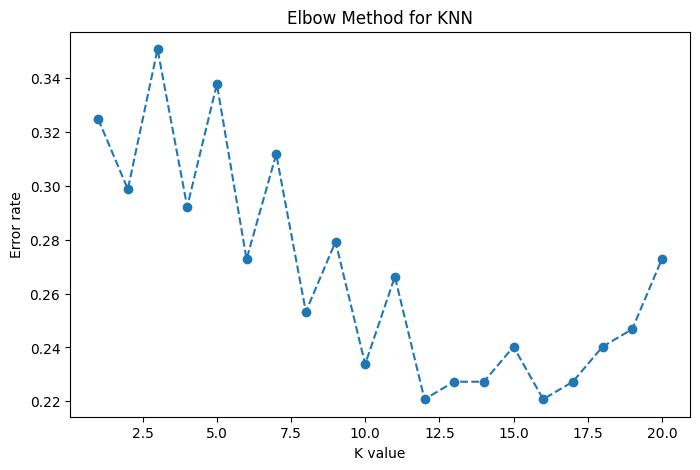

=== K-Nearest Neighbors Results ===
KNN (k=7) Accuracy: 0.6883116883116883
Confusion Matrix:
 [[72 27]
 [21 34]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.73      0.75        99
           1       0.56      0.62      0.59        55

    accuracy                           0.69       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.70      0.69      0.69       154



In [4]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

error_rates = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, y_pred))

plt.figure(figsize=(8,5))
plt.plot(range(1,21), error_rates, marker='o', linestyle='--')
plt.xlabel("K value")
plt.ylabel("Error rate")
plt.title("Elbow Method for KNN")
plt.show()

# Train with optimal K (example: 7)
optimal_k = 7
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("=== K-Nearest Neighbors Results ===")
print(f"KNN (k={optimal_k}) Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
